# 260318 새 출발

이 노트북은 `처음부터 다시` 시작하기 위한 작업용 페이지입니다.

현재 워크스페이스를 확인한 결과:
- 팀원별 작업 노트북과 파생 데이터는 있음
- `우리 팀원 말고` 외부 사람이 만든 따릉이 수요 예측 결과 데이터는 로컬 저장소에서 별도로 확인되지 않음
- 대신 새로 분석에 쓸 수 있는 원천/가공 데이터는 여러 개 있음


## 현재 확인한 데이터 후보

### 공용 원천 데이터
- `../../Data/sort_data/2024_data.parquet`
- `../../Data/sort_data/2025_data.parquet`
- `../../Data/정류장정보_시간대별_합친것.csv`

### 팀 내부 가공 데이터
- `../../Data/Zero/2024_data.csv`
- `../../Data/Zero/2025_data.csv`
- `../../Data/Restitutor/resti_dataset_2.csv`
- `../../Data/Restitutor/resti_dataset_3.csv`
- `../../Data/gtlee_data/sorted_data.csv`
- `../../Data/gtlee_data/gt_3구역_1027_2263_3126.csv`

### 참고
- `README.md` 기준으로 이 저장소는 팀원 개인 폴더(`LSH`, `Zero`, `HHJ`, `Restitutor`, `pluralize`, `이광태`) 중심으로 관리됨
- 그래서 현재 보이는 예측 산출물은 거의 전부 팀 내부 작업물로 보는 게 맞음


In [41]:
from pathlib import Path

base = Path('../../Data')

candidate_files = [
    base / 'sort_data' / '2024_data.parquet',
    base / 'sort_data' / '2025_data.parquet',
    base / '정류장정보_시간대별_합친것.csv',
    base / 'Zero' / '2024_data.csv',
    base / 'Zero' / '2025_data.csv',
    base / 'Restitutor' / 'resti_dataset_2.csv',
    base / 'Restitutor' / 'resti_dataset_3.csv',
    base / 'gtlee_data' / 'sorted_data.csv',
    base / 'gtlee_data' / 'gt_3구역_1027_2263_3126.csv',
]

for path in candidate_files:
    print(f'{path}: {path.exists()}')


../../Data/sort_data/2024_data.parquet: True
../../Data/sort_data/2025_data.parquet: True
../../Data/정류장정보_시간대별_합친것.csv: True
../../Data/Zero/2024_data.csv: True
../../Data/Zero/2025_data.csv: True
../../Data/Restitutor/resti_dataset_2.csv: True
../../Data/Restitutor/resti_dataset_3.csv: True
../../Data/gtlee_data/sorted_data.csv: True
../../Data/gtlee_data/gt_3구역_1027_2263_3126.csv: True


In [42]:
import pandas as pd

# sort_data 기준 2024, 2025 데이터를 합쳐서 사용
df_2024 = pd.read_parquet('../../Data/sort_data/2024_data.parquet')
df_2025 = pd.read_parquet('../../Data/sort_data/2025_data.parquet')
df = pd.concat([df_2024, df_2025], ignore_index=True)

print('df_2024 shape:', df_2024.shape)
print('df_2025 shape:', df_2025.shape)
print('combined df shape:', df.shape)
df.head()


df_2024 shape: (782915, 13)
df_2025 shape: (723743, 13)
combined df shape: (1506658, 13)


,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량
0,2024-01-01,17,출발시간,ST-479,ST-462,2.0,0 days 02:31:00,21873.0,4.3,78,41.94946,0.0,0.0
1,2024-01-01,16,출발시간,ST-460,ST-2425,1.0,0 days 00:11:00,550.0,6.1,65,45.87135,0.0,0.0
2,2024-01-01,16,출발시간,ST-461,ST-2425,1.0,0 days 00:15:00,1582.0,6.1,65,45.87135,0.0,0.0
3,2024-01-01,16,출발시간,ST-479,ST-479,1.0,0 days 00:22:00,2526.0,6.1,65,45.87135,0.0,0.0
4,2024-01-01,17,출발시간,ST-2264,ST-479,1.0,0 days 00:02:00,445.0,4.3,78,41.94946,0.0,0.0


## 내 담당 스테이션 3개

- `ST-464`
- `ST-481`
- `ST-479`

이제 이 3개를 기준으로 위치 정보와 기초 메타데이터를 확인합니다.


In [43]:
TARGET_STATIONS = ['ST-464', 'ST-481', 'ST-479']

station_meta = pd.read_csv('../../Data/은평_분기별_대여소_집계표.csv')
station_meta = station_meta[station_meta['대여소_ID'].isin(TARGET_STATIONS)].copy()
station_meta = station_meta.sort_values('대여소_ID').reset_index(drop=True)

station_meta[['대여소_ID', '주소1', '주소2', '위도', '경도', '연간_전체건수']]


,대여소_ID,주소1,주소2,위도,경도,연간_전체건수
0,ST-464,서울특별시 은평구 역촌동 15-40,평생학습관 앞,37.607849,126.921326,32581
1,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,68748
2,ST-481,서울특별시 은평구 서오릉로 163,LG서비스 역촌점,37.612484,126.914879,45879


## 한글 패치

그래프와 표에서 한글이 깨지지 않도록 먼저 폰트를 설정합니다.


In [44]:
import os
os.environ['MPLCONFIGDIR'] = '/tmp/matplotlib'

import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

preferred_fonts = ['AppleGothic', 'Malgun Gothic', 'NanumGothic']
available_fonts = {font.name for font in fm.fontManager.ttflist}
selected_font = next((font for font in preferred_fonts if font in available_fonts), None)

if selected_font is not None:
    plt.rcParams['font.family'] = selected_font
plt.rcParams['axes.unicode_minus'] = False

print('selected_font =', selected_font)


selected_font = AppleGothic


## 지도에 표시하기

`folium`으로 실제 지도를 만들고, 파일로도 저장합니다.


In [45]:
import folium
from pathlib import Path

plot_df = station_meta.copy()
plot_df['주소2'] = plot_df['주소2'].fillna('상세 주소 없음')

center_lat = plot_df['위도'].mean()
center_lon = plot_df['경도'].mean()
station_map = folium.Map(location=[center_lat, center_lon], zoom_start=15, tiles='OpenStreetMap')

marker_colors = {
    'ST-464': 'red',
    'ST-479': 'blue',
    'ST-481': 'green',
}

for _, row in plot_df.iterrows():
    popup_html = f'''
    <b>{row['대여소_ID']}</b><br>
    주소1: {row['주소1']}<br>
    주소2: {row['주소2']}<br>
    연간 전체건수: {int(row['연간_전체건수']):,}건
    '''
    folium.Marker(
        location=[row['위도'], row['경도']],
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=f"{row['대여소_ID']} / {row['주소2']}",
        icon=folium.Icon(color=marker_colors.get(row['대여소_ID'], 'cadetblue'), icon='info-sign')
    ).add_to(station_map)

map_output_path = Path('station_map_260318.html')
station_map.save(map_output_path)
print(f'html 저장 완료: {map_output_path.resolve()}')
station_map


html 저장 완료: /Users/isanghyeon/Documents/EP_cycle_stations/Note/LSH/station_map_260318.html


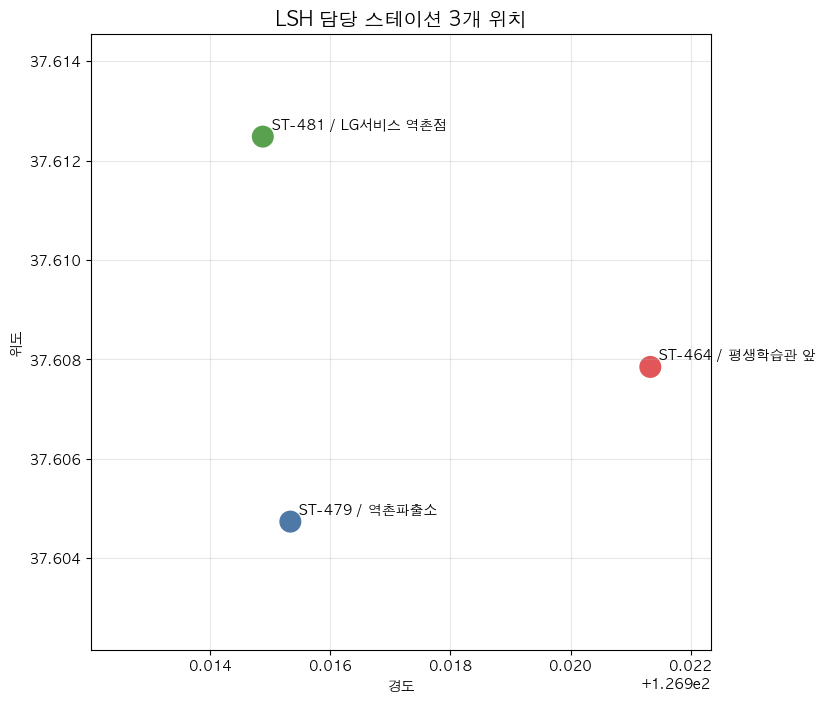

In [46]:
plot_df = station_meta.copy()
plot_df['label'] = plot_df['대여소_ID'] + ' / ' + plot_df['주소2'].fillna('주소2 없음')

center_lat = plot_df['위도'].mean()
center_lon = plot_df['경도'].mean()
lat_margin = max((plot_df['위도'].max() - plot_df['위도'].min()) * 0.8, 0.003)
lon_margin = max((plot_df['경도'].max() - plot_df['경도'].min()) * 0.8, 0.003)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(plot_df['경도'], plot_df['위도'], s=220, c=['#e15759', '#4e79a7', '#59a14f'])

for _, row in plot_df.iterrows():
    ax.text(
        row['경도'] + 0.00015,
        row['위도'] + 0.00015,
        row['label'],
        fontsize=10,
        weight='bold'
    )

ax.set_title('LSH 담당 스테이션 3개 위치', fontsize=14, weight='bold')
ax.set_xlabel('경도')
ax.set_ylabel('위도')
ax.set_xlim(center_lon - lon_margin, center_lon + lon_margin)
ax.set_ylim(center_lat - lat_margin, center_lat + lat_margin)
ax.grid(alpha=0.3)
plt.show()


In [47]:
station_meta[['대여소_ID', '주소1', '주소2', '위도', '경도', '연간_전체건수']].sort_values('연간_전체건수', ascending=False)


,대여소_ID,주소1,주소2,위도,경도,연간_전체건수
1,ST-479,서울특별시 은평구 역촌동 45-34,역촌파출소,37.604736,126.915337,68748
2,ST-481,서울특별시 은평구 서오릉로 163,LG서비스 역촌점,37.612484,126.914879,45879
0,ST-464,서울특별시 은평구 역촌동 15-40,평생학습관 앞,37.607849,126.921326,32581


## 타겟 스테이션 포함 행만 추출

아래 코드는 `sort_data`의 2024, 2025 통합 데이터에서 `시작_대여소_ID` 또는 `종료_대여소_ID`가 타겟 스테이션인 행만 따로 모읍니다.


In [48]:
target_station_set = set(TARGET_STATIONS)

target_trip_df = df[
    df['시작_대여소_ID'].isin(target_station_set)
    | df['종료_대여소_ID'].isin(target_station_set)
].copy()

print('원본 행 수:', len(df))
print('타겟 포함 행 수:', len(target_trip_df))
target_trip_df.head()


원본 행 수: 1506658
타겟 포함 행 수: 483720


,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량
0,2024-01-01,17,출발시간,ST-479,ST-462,2.0,0 days 02:31:00,21873.0,4.3,78,41.94946,0.0,0.0
3,2024-01-01,16,출발시간,ST-479,ST-479,1.0,0 days 00:22:00,2526.0,6.1,65,45.87135,0.0,0.0
4,2024-01-01,17,출발시간,ST-2264,ST-479,1.0,0 days 00:02:00,445.0,4.3,78,41.94946,0.0,0.0
7,2024-01-01,17,출발시간,ST-479,ST-479,1.0,0 days 00:16:00,169.0,4.3,78,41.94946,0.0,0.0
12,2024-01-01,17,출발시간,ST-464,ST-463,3.0,0 days 01:05:00,8110.0,4.3,78,41.94946,0.0,0.0


In [49]:
target_trip_df['타겟_포함_유형'] = '둘다 아님'
target_trip_df.loc[
    target_trip_df['시작_대여소_ID'].isin(target_station_set),
    '타겟_포함_유형'
] = '출발'
target_trip_df.loc[
    target_trip_df['종료_대여소_ID'].isin(target_station_set),
    '타겟_포함_유형'
] = '도착'
target_trip_df.loc[
    target_trip_df['시작_대여소_ID'].isin(target_station_set)
    & target_trip_df['종료_대여소_ID'].isin(target_station_set),
    '타겟_포함_유형'
] = '출발+도착'

display_cols = [
    '기준_날짜', '시간대', '집계_기준',
    '시작_대여소_ID', '종료_대여소_ID',
    '전체_건수', '전체_이용_분', '전체_이용_거리',
    '온도', '습도', '강수량', '적설량',
    '타겟_포함_유형'
]

target_trip_df[display_cols].head(10)


,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,강수량,적설량,타겟_포함_유형
0,2024-01-01,17,출발시간,ST-479,ST-462,2.0,0 days 02:31:00,21873.0,4.3,78,0.0,0.0,출발
3,2024-01-01,16,출발시간,ST-479,ST-479,1.0,0 days 00:22:00,2526.0,6.1,65,0.0,0.0,출발+도착
4,2024-01-01,17,출발시간,ST-2264,ST-479,1.0,0 days 00:02:00,445.0,4.3,78,0.0,0.0,도착
7,2024-01-01,17,출발시간,ST-479,ST-479,1.0,0 days 00:16:00,169.0,4.3,78,0.0,0.0,출발+도착
12,2024-01-01,17,출발시간,ST-464,ST-463,3.0,0 days 01:05:00,8110.0,4.3,78,0.0,0.0,출발
14,2024-01-01,16,출발시간,ST-2264,ST-479,1.0,0 days 00:02:00,0.0,6.1,65,0.0,0.0,도착
17,2024-01-01,17,출발시간,ST-2264,ST-479,1.0,0 days 00:02:00,0.0,4.3,78,0.0,0.0,도착
19,2024-01-01,17,출발시간,ST-455,ST-479,1.0,0 days 00:04:00,612.0,4.3,78,0.0,0.0,도착
27,2024-01-01,16,출발시간,ST-479,ST-454,1.0,0 days 00:07:00,1390.0,6.1,65,0.0,0.0,출발
31,2024-01-01,16,출발시간,ST-479,ST-1482,1.0,0 days 00:17:00,1384.0,6.1,65,0.0,0.0,출발


In [50]:
target_trip_df['타겟_포함_유형'].value_counts()


타겟_포함_유형
도착       227939
출발       215534
출발+도착     40247
Name: count, dtype: int64

## 시간대별 입출입 이벤트 만들기

기준 데이터는 모두 `출발시간` 기준이므로,
- 출발 시점에는 해당 스테이션에서 `전체_건수`만큼 유출
- `전체_이용_분`을 더해 계산한 도착 시점에는 도착 스테이션으로 `전체_건수`만큼 유입

으로 처리합니다.


In [51]:
stock_meta = pd.read_csv('../../Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv')
stock_meta = stock_meta[stock_meta['대여소_ID'].isin(TARGET_STATIONS)].copy()
stock_meta['initial_bikes'] = stock_meta[['LCD', 'QR']].fillna(0).sum(axis=1)

stock_meta[['대여소_ID', 'LCD', 'QR', 'initial_bikes', '위도', '경도']].sort_values('대여소_ID')


,대여소_ID,LCD,QR,initial_bikes,위도,경도
62,ST-464,13.0,0.0,13.0,37.607849,126.921326
60,ST-479,19.0,0.0,19.0,37.604736,126.915337
61,ST-481,15.0,0.0,15.0,37.612484,126.914879


In [52]:
event_base = target_trip_df.copy()
event_base['출발_datetime'] = pd.to_datetime(event_base['기준_날짜']) + pd.to_timedelta(event_base['시간대'], unit='h')
event_base['도착_datetime'] = event_base['출발_datetime'] + event_base['전체_이용_분']
event_base['도착_시간대'] = event_base['도착_datetime'].dt.floor('h')

event_base[
    [
        '기준_날짜', '시간대', '시작_대여소_ID', '종료_대여소_ID',
        '전체_건수', '전체_이용_분', '출발_datetime', '도착_datetime', '도착_시간대'
    ]
].head(10)


,기준_날짜,시간대,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,출발_datetime,도착_datetime,도착_시간대
0,2024-01-01,17,ST-479,ST-462,2.0,0 days 02:31:00,2024-01-01 17:00:00,2024-01-01 19:31:00,2024-01-01 19:00:00
3,2024-01-01,16,ST-479,ST-479,1.0,0 days 00:22:00,2024-01-01 16:00:00,2024-01-01 16:22:00,2024-01-01 16:00:00
4,2024-01-01,17,ST-2264,ST-479,1.0,0 days 00:02:00,2024-01-01 17:00:00,2024-01-01 17:02:00,2024-01-01 17:00:00
7,2024-01-01,17,ST-479,ST-479,1.0,0 days 00:16:00,2024-01-01 17:00:00,2024-01-01 17:16:00,2024-01-01 17:00:00
12,2024-01-01,17,ST-464,ST-463,3.0,0 days 01:05:00,2024-01-01 17:00:00,2024-01-01 18:05:00,2024-01-01 18:00:00
14,2024-01-01,16,ST-2264,ST-479,1.0,0 days 00:02:00,2024-01-01 16:00:00,2024-01-01 16:02:00,2024-01-01 16:00:00
17,2024-01-01,17,ST-2264,ST-479,1.0,0 days 00:02:00,2024-01-01 17:00:00,2024-01-01 17:02:00,2024-01-01 17:00:00
19,2024-01-01,17,ST-455,ST-479,1.0,0 days 00:04:00,2024-01-01 17:00:00,2024-01-01 17:04:00,2024-01-01 17:00:00
27,2024-01-01,16,ST-479,ST-454,1.0,0 days 00:07:00,2024-01-01 16:00:00,2024-01-01 16:07:00,2024-01-01 16:00:00
31,2024-01-01,16,ST-479,ST-1482,1.0,0 days 00:17:00,2024-01-01 16:00:00,2024-01-01 16:17:00,2024-01-01 16:00:00


In [53]:
outflow_events = event_base[event_base['시작_대여소_ID'].isin(target_station_set)].copy()
outflow_events = outflow_events.assign(
    대여소_ID=outflow_events['시작_대여소_ID'],
    event_datetime=outflow_events['출발_datetime'].dt.floor('h'),
    outflow_count=outflow_events['전체_건수'],
    inflow_count=0
)

inflow_events = event_base[event_base['종료_대여소_ID'].isin(target_station_set)].copy()
inflow_events = inflow_events.assign(
    대여소_ID=inflow_events['종료_대여소_ID'],
    event_datetime=inflow_events['도착_datetime'].dt.floor('h'),
    outflow_count=0,
    inflow_count=inflow_events['전체_건수']
)

station_events = pd.concat([
    outflow_events[['대여소_ID', 'event_datetime', 'inflow_count', 'outflow_count']],
    inflow_events[['대여소_ID', 'event_datetime', 'inflow_count', 'outflow_count']]
], ignore_index=True)

station_events = station_events.sort_values(['대여소_ID', 'event_datetime']).reset_index(drop=True)
station_events.head(10)


,대여소_ID,event_datetime,inflow_count,outflow_count
0,ST-464,2024-01-01 00:00:00,0.0,1.0
1,ST-464,2024-01-01 00:00:00,0.0,1.0
2,ST-464,2024-01-01 00:00:00,1.0,0.0
3,ST-464,2024-01-01 01:00:00,1.0,0.0
4,ST-464,2024-01-01 01:00:00,1.0,0.0
5,ST-464,2024-01-01 01:00:00,1.0,0.0
6,ST-464,2024-01-01 01:00:00,1.0,0.0
7,ST-464,2024-01-01 02:00:00,0.0,1.0
8,ST-464,2024-01-01 02:00:00,0.0,1.0
9,ST-464,2024-01-01 03:00:00,0.0,1.0


In [54]:
hourly_flow = station_events.groupby(['대여소_ID', 'event_datetime'], as_index=False).agg({
    'inflow_count': 'sum',
    'outflow_count': 'sum'
})

hourly_flow['net_flow'] = hourly_flow['inflow_count'] - hourly_flow['outflow_count']
hourly_flow['날짜'] = hourly_flow['event_datetime'].dt.date
hourly_flow['시간대'] = hourly_flow['event_datetime'].dt.hour

hourly_flow.head(10)


,대여소_ID,event_datetime,inflow_count,outflow_count,net_flow,날짜,시간대
0,ST-464,2024-01-01 00:00:00,1.0,2.0,-1.0,2024-01-01,0
1,ST-464,2024-01-01 01:00:00,4.0,0.0,4.0,2024-01-01,1
2,ST-464,2024-01-01 02:00:00,0.0,2.0,-2.0,2024-01-01,2
3,ST-464,2024-01-01 03:00:00,0.0,2.0,-2.0,2024-01-01,3
4,ST-464,2024-01-01 09:00:00,2.0,0.0,2.0,2024-01-01,9
5,ST-464,2024-01-01 10:00:00,0.0,2.0,-2.0,2024-01-01,10
6,ST-464,2024-01-01 13:00:00,2.0,0.0,2.0,2024-01-01,13
7,ST-464,2024-01-01 14:00:00,2.0,4.0,-2.0,2024-01-01,14
8,ST-464,2024-01-01 15:00:00,6.0,0.0,6.0,2024-01-01,15
9,ST-464,2024-01-01 16:00:00,5.0,6.0,-1.0,2024-01-01,16


In [55]:
full_time_index = pd.MultiIndex.from_product(
    [
        sorted(TARGET_STATIONS),
        pd.date_range(hourly_flow['event_datetime'].min(), hourly_flow['event_datetime'].max(), freq='h')
    ],
    names=['대여소_ID', 'event_datetime']
)

hourly_full = pd.DataFrame(index=full_time_index).reset_index()
hourly_full = hourly_full.merge(hourly_flow, on=['대여소_ID', 'event_datetime'], how='left')
hourly_full[['inflow_count', 'outflow_count', 'net_flow']] = hourly_full[['inflow_count', 'outflow_count', 'net_flow']].fillna(0)
hourly_full['날짜'] = hourly_full['event_datetime'].dt.date
hourly_full['시간대'] = hourly_full['event_datetime'].dt.hour

initial_stock_map = stock_meta.set_index('대여소_ID')['initial_bikes']
hourly_full['initial_bikes'] = hourly_full['대여소_ID'].map(initial_stock_map)

# 첫 시점 재고를 LCD + QR로 두고, 이후 시간순 누적으로 추정한다.
hourly_full['cum_net_flow_before'] = hourly_full.groupby('대여소_ID')['net_flow'].cumsum() - hourly_full['net_flow']
hourly_full['estimated_stock_start'] = hourly_full['initial_bikes'] + hourly_full['cum_net_flow_before']
hourly_full['estimated_stock_end'] = hourly_full['estimated_stock_start'] + hourly_full['net_flow']

hourly_full.head(10)


,대여소_ID,event_datetime,inflow_count,outflow_count,net_flow,날짜,시간대,initial_bikes,cum_net_flow_before,estimated_stock_start,estimated_stock_end
0,ST-464,2024-01-01 00:00:00,1.0,2.0,-1.0,2024-01-01,0,13.0,0.0,13.0,12.0
1,ST-464,2024-01-01 01:00:00,4.0,0.0,4.0,2024-01-01,1,13.0,-1.0,12.0,16.0
2,ST-464,2024-01-01 02:00:00,0.0,2.0,-2.0,2024-01-01,2,13.0,3.0,16.0,14.0
3,ST-464,2024-01-01 03:00:00,0.0,2.0,-2.0,2024-01-01,3,13.0,1.0,14.0,12.0
4,ST-464,2024-01-01 04:00:00,0.0,0.0,0.0,2024-01-01,4,13.0,-1.0,12.0,12.0
5,ST-464,2024-01-01 05:00:00,0.0,0.0,0.0,2024-01-01,5,13.0,-1.0,12.0,12.0
6,ST-464,2024-01-01 06:00:00,0.0,0.0,0.0,2024-01-01,6,13.0,-1.0,12.0,12.0
7,ST-464,2024-01-01 07:00:00,0.0,0.0,0.0,2024-01-01,7,13.0,-1.0,12.0,12.0
8,ST-464,2024-01-01 08:00:00,0.0,0.0,0.0,2024-01-01,8,13.0,-1.0,12.0,12.0
9,ST-464,2024-01-01 09:00:00,2.0,0.0,2.0,2024-01-01,9,13.0,-1.0,12.0,14.0


In [56]:
hourly_station_summary = hourly_full[
    [
        '대여소_ID', 'event_datetime', '날짜', '시간대',
        'initial_bikes', 'inflow_count', 'outflow_count', 'net_flow',
        'estimated_stock_start', 'estimated_stock_end'
    ]
].copy()

hourly_station_summary.head(20)


,대여소_ID,event_datetime,날짜,시간대,initial_bikes,inflow_count,outflow_count,net_flow,estimated_stock_start,estimated_stock_end
0,ST-464,2024-01-01 00:00:00,2024-01-01,0,13.0,1.0,2.0,-1.0,13.0,12.0
1,ST-464,2024-01-01 01:00:00,2024-01-01,1,13.0,4.0,0.0,4.0,12.0,16.0
2,ST-464,2024-01-01 02:00:00,2024-01-01,2,13.0,0.0,2.0,-2.0,16.0,14.0
3,ST-464,2024-01-01 03:00:00,2024-01-01,3,13.0,0.0,2.0,-2.0,14.0,12.0
4,ST-464,2024-01-01 04:00:00,2024-01-01,4,13.0,0.0,0.0,0.0,12.0,12.0
5,ST-464,2024-01-01 05:00:00,2024-01-01,5,13.0,0.0,0.0,0.0,12.0,12.0
6,ST-464,2024-01-01 06:00:00,2024-01-01,6,13.0,0.0,0.0,0.0,12.0,12.0
7,ST-464,2024-01-01 07:00:00,2024-01-01,7,13.0,0.0,0.0,0.0,12.0,12.0
8,ST-464,2024-01-01 08:00:00,2024-01-01,8,13.0,0.0,0.0,0.0,12.0,12.0
9,ST-464,2024-01-01 09:00:00,2024-01-01,9,13.0,2.0,0.0,2.0,12.0,14.0


In [57]:
hourly_station_summary.groupby('대여소_ID')[['inflow_count', 'outflow_count']].sum()


,inflow_count,outflow_count
대여소_ID,,
ST-464,55841.0,56286.0
ST-479,139445.0,130744.0
ST-481,84989.0,81734.0


In [ ]:
# 아래 셀부터 시간대별 잔여 대수 예측 모델링을 진행한다.


## 시간대별 잔여 대수 예측 준비

현재 재고는 이벤트 누적으로 만든 추정치이므로, 학습 타깃은 우선 `0 ~ initial_bikes` 범위로 잘라서 사용합니다.


In [58]:
model_df = hourly_station_summary.copy()
model_df = model_df.sort_values(['대여소_ID', 'event_datetime']).reset_index(drop=True)

model_df['capacity_proxy'] = model_df['initial_bikes']
model_df['estimated_stock_start_clipped'] = model_df['estimated_stock_start'].clip(lower=0)
model_df['estimated_stock_end_clipped'] = model_df.apply(
    lambda row: min(max(row['estimated_stock_end'], 0), row['capacity_proxy']),
    axis=1
)

model_df['weekday'] = model_df['event_datetime'].dt.weekday
model_df['month'] = model_df['event_datetime'].dt.month
model_df['is_weekend'] = (model_df['weekday'] >= 5).astype(int)

for lag in [1, 2, 3, 6, 12, 24]:
    model_df[f'lag_stock_end_{lag}'] = model_df.groupby('대여소_ID')['estimated_stock_end_clipped'].shift(lag)
    model_df[f'lag_inflow_{lag}'] = model_df.groupby('대여소_ID')['inflow_count'].shift(lag)
    model_df[f'lag_outflow_{lag}'] = model_df.groupby('대여소_ID')['outflow_count'].shift(lag)

for window in [3, 6, 12, 24]:
    model_df[f'roll_outflow_mean_{window}'] = (
        model_df.groupby('대여소_ID')['outflow_count']
        .transform(lambda s: s.shift(1).rolling(window).mean())
    )
    model_df[f'roll_inflow_mean_{window}'] = (
        model_df.groupby('대여소_ID')['inflow_count']
        .transform(lambda s: s.shift(1).rolling(window).mean())
    )

model_df.head(10)


,대여소_ID,event_datetime,날짜,시간대,initial_bikes,inflow_count,outflow_count,net_flow,estimated_stock_start,estimated_stock_end,...,lag_inflow_24,lag_outflow_24,roll_outflow_mean_3,roll_inflow_mean_3,roll_outflow_mean_6,roll_inflow_mean_6,roll_outflow_mean_12,roll_inflow_mean_12,roll_outflow_mean_24,roll_inflow_mean_24
0,ST-464,2024-01-01 00:00:00,2024-01-01,0,13.0,1.0,2.0,-1.0,13.0,12.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ST-464,2024-01-01 01:00:00,2024-01-01,1,13.0,4.0,0.0,4.0,12.0,16.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ST-464,2024-01-01 02:00:00,2024-01-01,2,13.0,0.0,2.0,-2.0,16.0,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ST-464,2024-01-01 03:00:00,2024-01-01,3,13.0,0.0,2.0,-2.0,14.0,12.0,...,NaN,NaN,1.333333,1.666667,NaN,NaN,NaN,NaN,NaN,NaN
4,ST-464,2024-01-01 04:00:00,2024-01-01,4,13.0,0.0,0.0,0.0,12.0,12.0,...,NaN,NaN,1.333333,1.333333,NaN,NaN,NaN,NaN,NaN,NaN
5,ST-464,2024-01-01 05:00:00,2024-01-01,5,13.0,0.0,0.0,0.0,12.0,12.0,...,NaN,NaN,1.333333,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
6,ST-464,2024-01-01 06:00:00,2024-01-01,6,13.0,0.0,0.0,0.0,12.0,12.0,...,NaN,NaN,0.666667,0.000000,1.000000,0.833333,NaN,NaN,NaN,NaN
7,ST-464,2024-01-01 07:00:00,2024-01-01,7,13.0,0.0,0.0,0.0,12.0,12.0,...,NaN,NaN,0.000000,0.000000,0.666667,0.666667,NaN,NaN,NaN,NaN
8,ST-464,2024-01-01 08:00:00,2024-01-01,8,13.0,0.0,0.0,0.0,12.0,12.0,...,NaN,NaN,0.000000,0.000000,0.666667,0.000000,NaN,NaN,NaN,NaN
9,ST-464,2024-01-01 09:00:00,2024-01-01,9,13.0,2.0,0.0,2.0,12.0,14.0,...,NaN,NaN,0.000000,0.000000,0.333333,0.000000,NaN,NaN,NaN,NaN


In [59]:
feature_cols = [
    '시간대', 'weekday', 'month', 'is_weekend',
    'initial_bikes', 'capacity_proxy',
    'inflow_count', 'outflow_count', 'net_flow',
    'estimated_stock_start_clipped',
    'lag_stock_end_1', 'lag_stock_end_2', 'lag_stock_end_3', 'lag_stock_end_6', 'lag_stock_end_12', 'lag_stock_end_24',
    'lag_inflow_1', 'lag_inflow_2', 'lag_inflow_3', 'lag_inflow_6', 'lag_inflow_12', 'lag_inflow_24',
    'lag_outflow_1', 'lag_outflow_2', 'lag_outflow_3', 'lag_outflow_6', 'lag_outflow_12', 'lag_outflow_24',
    'roll_outflow_mean_3', 'roll_outflow_mean_6', 'roll_outflow_mean_12', 'roll_outflow_mean_24',
    'roll_inflow_mean_3', 'roll_inflow_mean_6', 'roll_inflow_mean_12', 'roll_inflow_mean_24'
]

target_col = 'estimated_stock_end_clipped'

model_ready_df = model_df.dropna(subset=feature_cols + [target_col]).copy()
model_ready_df['station_idx'] = pd.factorize(model_ready_df['대여소_ID'])[0]
feature_cols_with_station = feature_cols + ['station_idx']

print('model_ready_df shape:', model_ready_df.shape)
model_ready_df[['대여소_ID', 'event_datetime', target_col]].head()


model_ready_df shape: (52560, 43)


,대여소_ID,event_datetime,estimated_stock_end_clipped
24,ST-464,2024-01-02 00:00:00,10.0
25,ST-464,2024-01-02 01:00:00,10.0
26,ST-464,2024-01-02 02:00:00,10.0
27,ST-464,2024-01-02 03:00:00,10.0
28,ST-464,2024-01-02 04:00:00,10.0


In [60]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

split_point = model_ready_df['event_datetime'].quantile(0.8)
train_df = model_ready_df[model_ready_df['event_datetime'] < split_point].copy()
test_df = model_ready_df[model_ready_df['event_datetime'] >= split_point].copy()

X_train = train_df[feature_cols_with_station]
y_train = train_df[target_col]
X_test = test_df[feature_cols_with_station]
y_test = test_df[target_col]

stock_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
stock_model.fit(X_train, y_train)

pred_test = stock_model.predict(X_test)
pred_test = pred_test.clip(0, test_df['capacity_proxy'].to_numpy())

metrics = {
    'train_rows': len(train_df),
    'test_rows': len(test_df),
    'split_point': split_point,
    'mae': mean_absolute_error(y_test, pred_test),
    'rmse': mean_squared_error(y_test, pred_test) ** 0.5,
    'r2': r2_score(y_test, pred_test),
}
metrics


{'train_rows': 42048,
 'test_rows': 10512,
 'split_point': Timestamp('2025-08-07 23:12:00'),
 'mae': 0.00024076722904321776,
 'rmse': 0.004013707446690828,
 'r2': 0.9999997591551043}

In [61]:
prediction_df = test_df[['대여소_ID', 'event_datetime', '시간대', 'initial_bikes', target_col]].copy()
prediction_df['pred_stock_end'] = pred_test
prediction_df['abs_error'] = (prediction_df[target_col] - prediction_df['pred_stock_end']).abs()
prediction_df = prediction_df.sort_values(['대여소_ID', 'event_datetime']).reset_index(drop=True)
prediction_df.head(20)


,대여소_ID,event_datetime,시간대,initial_bikes,estimated_stock_end_clipped,pred_stock_end,abs_error
0,ST-464,2025-08-08 00:00:00,0,13.0,0.0,0.0,0.0
1,ST-464,2025-08-08 01:00:00,1,13.0,0.0,0.0,0.0
2,ST-464,2025-08-08 02:00:00,2,13.0,0.0,0.0,0.0
3,ST-464,2025-08-08 03:00:00,3,13.0,0.0,0.0,0.0
4,ST-464,2025-08-08 04:00:00,4,13.0,0.0,0.0,0.0
5,ST-464,2025-08-08 05:00:00,5,13.0,0.0,0.0,0.0
6,ST-464,2025-08-08 06:00:00,6,13.0,0.0,0.0,0.0
7,ST-464,2025-08-08 07:00:00,7,13.0,0.0,0.0,0.0
8,ST-464,2025-08-08 08:00:00,8,13.0,0.0,0.0,0.0
9,ST-464,2025-08-08 09:00:00,9,13.0,0.0,0.0,0.0


In [62]:
prediction_df.groupby('대여소_ID').agg(
    actual_mean=(target_col, 'mean'),
    pred_mean=('pred_stock_end', 'mean'),
    mae=('abs_error', 'mean')
).sort_index()


,actual_mean,pred_mean,mae
대여소_ID,,,
ST-464,0.0,0.000084,0.000084
ST-479,19.0,19.000000,0.000000
ST-481,15.0,14.999362,0.000638


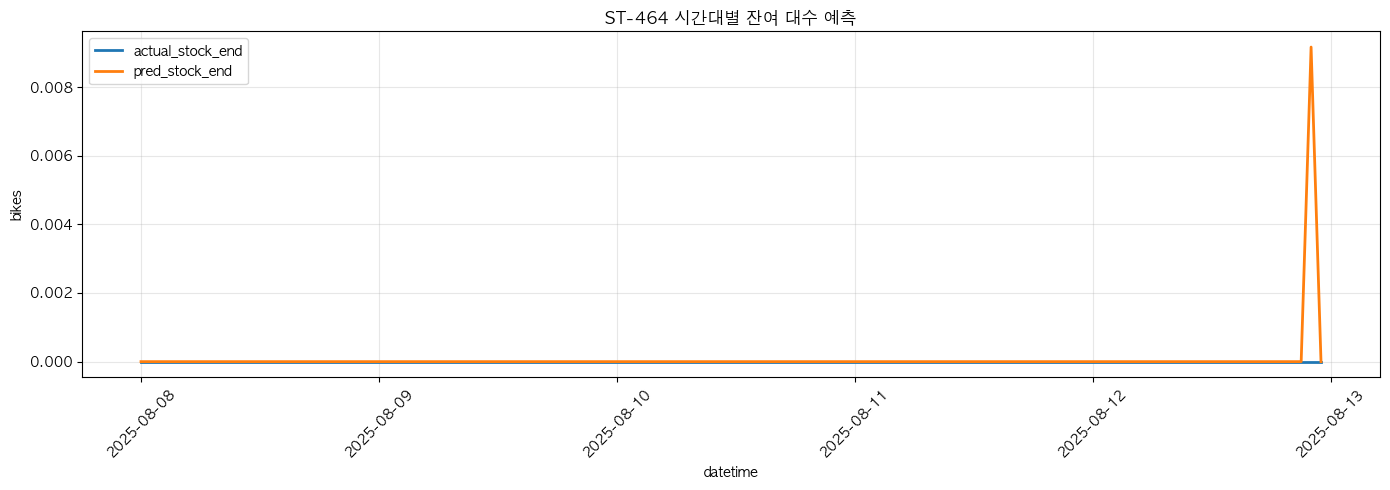

In [63]:
plot_station_id = prediction_df['대여소_ID'].iloc[0]
plot_df = prediction_df[prediction_df['대여소_ID'] == plot_station_id].head(120).copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_df['event_datetime'], plot_df[target_col], label='actual_stock_end', linewidth=2)
ax.plot(plot_df['event_datetime'], plot_df['pred_stock_end'], label='pred_stock_end', linewidth=2)
ax.set_title(f'{plot_station_id} 시간대별 잔여 대수 예측')
ax.set_xlabel('datetime')
ax.set_ylabel('bikes')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
